<a href="https://colab.research.google.com/github/aothmanboahen/Financial_Fraud_Detection_Systems/blob/main/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading the datasets

In [ ]:
import pandas as pd

df = pd.read_csv("/content/datarawcreditcard.csv")  # use your actual file

Clean target

In [ ]:
df = df.dropna(subset=["Class"])
df["Class"] = df["Class"].astype(int)

Defining Featurs and targets.

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

Spliting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for fraud detection
)

. RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"  # 🔥 IMPORTANT
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9979899497487437
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3963
           1       0.85      0.65      0.73        17

    accuracy                           1.00      3980
   macro avg       0.92      0.82      0.87      3980
weighted avg       1.00      1.00      1.00      3980



GRADIENT BOOSTING

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9979899497487437
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3963
           1       0.80      0.71      0.75        17

    accuracy                           1.00      3980
   macro avg       0.90      0.85      0.87      3980
weighted avg       1.00      1.00      1.00      3980



CONFUSION MATRIX (CRITICAL)

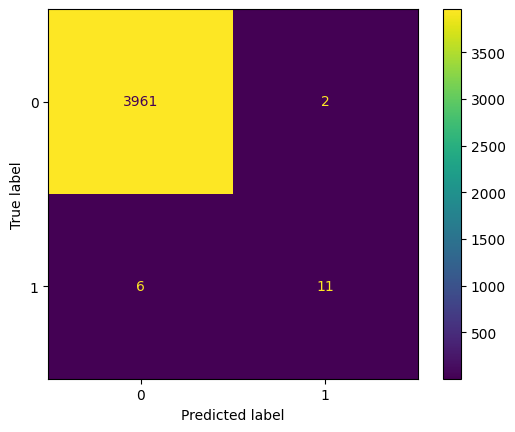

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

RECALL (MOST IMPORTANT METRIC)

In [ ]:
from sklearn.metrics import recall_score

print("RF Recall:", recall_score(y_test, y_pred_rf))
print("GB Recall:", recall_score(y_test, y_pred_gb))

RF Recall: 0.6470588235294118
GB Recall: 0.7058823529411765


PRECISION (BALANCE)

In [ ]:
from sklearn.metrics import precision_score

print("RF Precision:", precision_score(y_test, y_pred_rf))
print("GB Precision:", precision_score(y_test, y_pred_gb))

RF Precision: 0.8461538461538461
GB Precision: 0.8


ROC-AUC (PRO LEVEL)

In [ ]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])

print("RF ROC-AUC:", rf_auc)
print("GB ROC-AUC:", gb_auc)

RF ROC-AUC: 0.9395511421828383
GB ROC-AUC: 0.8506627480666755


MODEL COMPARISON

In [ ]:
models = ["Random Forest", "Gradient Boosting"]
recalls = [
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_gb)
]

for model, rec in zip(models, recalls):
    print(f"{model} Recall: {rec}")

Random Forest Recall: 0.6470588235294118
Gradient Boosting Recall: 0.7058823529411765


**HANDLING IMBALANCED DATA**
*“Teach the Model to Care About Fraud”*

APPLYING SMOTE (OVERSAMPLING)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Check new distribution

In [ ]:
import pandas as pd

pd.Series(y_train_smote).value_counts()

,count
Class,
0,15849
1,15849


TRAIN MODEL WITH SMOTE DATA

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

EVALUATE

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3963
           1       0.87      0.76      0.81        17

    accuracy                           1.00      3980
   macro avg       0.93      0.88      0.91      3980
weighted avg       1.00      1.00      1.00      3980



Apply undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

Train model

In [ ]:
rf_under = RandomForestClassifier(random_state=42)
rf_under.fit(X_train_under, y_train_under)

y_pred_under = rf_under.predict(X_test)

EVALUATE

In [ ]:
print(classification_report(y_test, y_pred_under))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3963
           1       0.25      0.82      0.39        17

    accuracy                           0.99      3980
   macro avg       0.63      0.91      0.69      3980
weighted avg       1.00      0.99      0.99      3980



CLASS WEIGHT (BASELINE)

In [ ]:
RandomForestClassifier(class_weight="balanced")

RandomForestClassifier(class_weight='balanced')

COMPARE ALL METHODS

In [ ]:
from sklearn.metrics import recall_score

print("Original Recall:", recall_score(y_test, y_pred_rf))
print("SMOTE Recall:", recall_score(y_test, y_pred_smote))
print("Undersampling Recall:", recall_score(y_test, y_pred_under))

Original Recall: 0.6470588235294118
SMOTE Recall: 0.7647058823529411
Undersampling Recall: 0.8235294117647058


ADVANCED MOVE (Combine SMOTE + Model)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_smote = GradientBoostingClassifier()
gb_smote.fit(X_train_smote, y_train_smote)

y_pred_gb_smote = gb_smote.predict(X_test)

**EVALUATION & OPTIMIZATION**
*“Make the Fraud Model Robust and High-Performing”*


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="recall"   # 🔥 Focus on fraud detection
)

print("CV Recall Scores:", cv_scores)
print("Mean Recall:", cv_scores.mean())

CV Recall Scores: [1. 1. 1. 1. 1.]
Mean Recall: 1.0


Define parameter grid

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

Run GridSearch

In [ ]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

Best parameters

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Recall:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Recall: 0.9999369045365638


TRAIN OPTIMIZED MODEL

In [ ]:
best_model = grid.best_estimator_

best_model.fit(X_train_smote, y_train_smote)

y_pred_best = best_model.predict(X_test)

FINAL EVALUATION

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

CONFUSION MATRIX (CRITICAL)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot()

ROC-AUC

In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
print("ROC-AUC:", roc)

ROC-AUC: 0.9941369431951433


THRESHOLD TUNING (ADVANCED — VERY IMPORTANT)

In [ ]:
y_probs = best_model.predict_proba(X_test)[:,1]

import numpy as np

threshold = 0.3  # lower threshold → more fraud detected

y_pred_custom = (y_probs > threshold).astype(int)

Evaluate new threshold

In [ ]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3963
           1       0.88      0.82      0.85        17

    accuracy                           1.00      3980
   macro avg       0.94      0.91      0.92      3980
weighted avg       1.00      1.00      1.00      3980

